In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_excel("all_data_M_2023.xlsx")
df.head()

,AREA,AREA_TITLE,AREA_TYPE,PRIM_STATE,NAICS,NAICS_TITLE,I_GROUP,OWN_CODE,OCC_CODE,OCC_TITLE,...,H_MEDIAN,H_PCT75,H_PCT90,A_PCT10,A_PCT25,A_MEDIAN,A_PCT75,A_PCT90,ANNUAL,HOURLY
0,99,U.S.,1,US,000000,Cross-industry,cross-industry,1235,00-0000,All Occupations,...,23.11,37.01,58.4,29050,35660,48060,76980,121470,NaN,NaN
1,99,U.S.,1,US,000000,Cross-industry,cross-industry,1235,11-0000,Management Occupations,...,56.19,81.29,111.36,54550,78330,116880,169090,231620,NaN,NaN
2,99,U.S.,1,US,000000,Cross-industry,cross-industry,1235,11-1000,Top Executives,...,49.74,79.57,#,46400,66170,103460,165500,#,NaN,NaN
3,99,U.S.,1,US,000000,Cross-industry,cross-industry,1235,11-1010,Chief Executives,...,99.37,#,#,80000,130840,206680,#,#,NaN,NaN
4,99,U.S.,1,US,000000,Cross-industry,cross-industry,1235,11-1011,Chief Executives,...,99.37,#,#,80000,130840,206680,#,#,NaN,NaN


In [4]:
codes = ["15-1221",   # Computer and Information Research Scientists 
         "15-2051",   # Data Scientists
         "15-2041",   # Statisticians
         "15-1252",   # Software Developers
         "15-1251",   # Computer Programmers
         "15-1254"]   # Web Developers

jobs = df[ df["OCC_CODE"].isin(codes) ].copy()

# Turn the number columns into real numbers (BLS uses * and # for missing values)
cols = ["TOT_EMP", "A_PCT10", "A_PCT25", "A_MEDIAN", "A_PCT75", "A_PCT90"]
for c in cols:
    jobs[c] = pd.to_numeric(jobs[c], errors="coerce")

national = jobs[ (jobs["AREA_TYPE"] == 1) & (jobs["I_GROUP"] == "cross-industry") ]
states = jobs[ jobs["AREA_TYPE"] == 2 ]

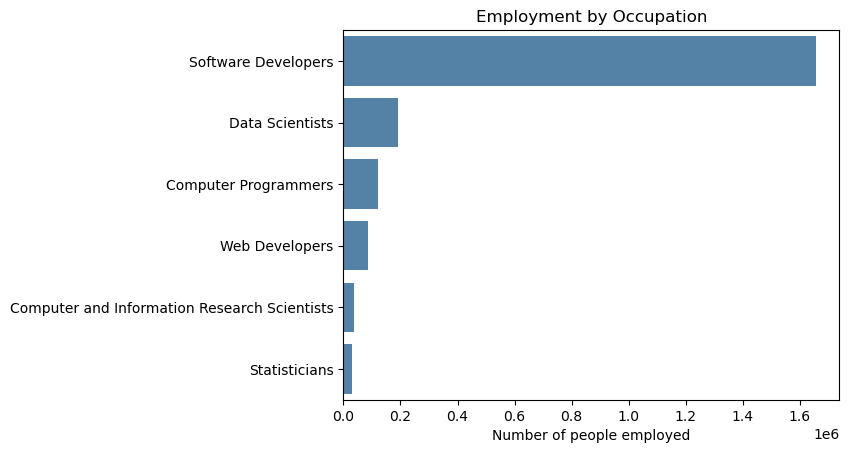

In [7]:
sns.barplot(data=national.sort_values("TOT_EMP", ascending=False),
            x="TOT_EMP", y="OCC_TITLE", color="steelblue")
plt.title("Employment by Occupation")
plt.xlabel("Number of people employed")
plt.ylabel("")
plt.show()